# Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages # Reducers

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
base_url = os.getenv("OPENAI_BASE_URL")
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4",
    api_key=api_key,
    base_url=base_url
)
llm.invoke("Hello")

AIMessage(content='Hello! 😊 How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 8, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKNcKQfmWUWV2cdCjtojXMGTPbJKL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfbb8-c256-7b42-892f-6260298ab285-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 11, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## We will start With Creating Nodes

In [6]:
def superbot(state: State):

    return {"messages": [llm.invoke(state['messages'])]}

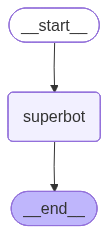

In [7]:
graph = StateGraph(State)

graph.add_node("superbot", superbot)

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile()

graph_builder

In [8]:
# Invocation
graph_builder.invoke({"messages": "What is the capital of France?"})

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='1fc4cf44-799c-4f8a-81a0-ede4771c2428'),
  AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 14, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKNhtAnEVjNOfUbplniYN9VUvmg0L', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfbbe-0657-7ae1-ac2e-7eae430b1593-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 10, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0,

In [9]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"}):
    print(event)

{'superbot': {'messages': [AIMessage(content='Hello Krish! Nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 13, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKNjOsOTRuPAwOstskDP7yUxa162M', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfbbf-7158-7e72-8e22-3ad14526269c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 17, 'total_tokens': 30, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [10]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is KRish', additional_kwargs={}, response_metadata={}, id='1edc1476-73b6-455c-bc3a-2ce41e4dd7aa')]}
{'messages': [HumanMessage(content='Hello My name is KRish', additional_kwargs={}, response_metadata={}, id='1edc1476-73b6-455c-bc3a-2ce41e4dd7aa'), AIMessage(content='Hello, Krish! 👋 How are you doing today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 13, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DKNkivBZLTnDfzbDLxXWYQc62FMux', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfbc0-b192-7f42-960c-d50b92d5f883-0', tool_calls=[], invalid_tool_calls